## Продолжение Сессии 7. Задача: Рассчет волатильности выручки по категориям, Рассчет логистических рисков по штатам

In [8]:
import pandas as pd 

df_data = pd.read_csv('data_from_notes/full_data.csv', sep = ';')


cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'shipping_limit_date', 'review_creation_date', 'review_answer_timestamp']
for col in cols:
    df_data[col] = pd.to_datetime(df_data[col], format = 'mixed')

# Создадим колонку дней доставки, для дальнейшей работы
df_data['delivery_days'] = (df_data['order_delivered_customer_date'] - df_data['order_purchase_timestamp']).dt.days.astype('float32')

# Удалим технические флаги, которые не несут в себе полезной информации
df_data.drop(columns = ['is_delivered', 'confirm', 'conf_&_paid'], inplace = True)

# Создадим флаг, который поможет оставить только те заказы и строки, по которым доставка была действительно произведена, что соответствует цели исследования
df_data['delivered'] = df_data['delivery_days'].notna()

# Оставим только те заказы, доставка которых была произведена и посчитана ранее
df_data = df_data[df_data['delivered']]
df_data = df_data.drop(columns = ['delivered'])

# Отфильтруем данные по дате, так как начальные и конечные месяцы датафрейма имеют неполные данные о месяцах
start_date = '2017-01-01'
end_date = '2018-08-31'

date_mask = (df_data['order_purchase_timestamp'] >= start_date) & (df_data['order_purchase_timestamp'] <= end_date)
data = df_data[date_mask].copy()
# Посмотрим на полученный датафрейм кратко
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 89808 entries, 0 to 92036
Data columns (total 44 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       89808 non-null  object        
 1   customer_id                    89808 non-null  object        
 2   order_status                   89808 non-null  object        
 3   order_purchase_timestamp       89808 non-null  datetime64[ns]
 4   order_approved_at              89796 non-null  datetime64[ns]
 5   order_delivered_carrier_date   89807 non-null  datetime64[ns]
 6   order_delivered_customer_date  89808 non-null  datetime64[ns]
 7   order_estimated_delivery_date  89808 non-null  datetime64[ns]
 8   customer_unique_id             89808 non-null  object        
 9   customer_zip_code_prefix       89808 non-null  int64         
 10  customer_city                  89808 non-null  object        
 11  customer_state      

После того, как мы подготовили данные и убедились в их корректности перейдем к решению первой задачи - **Рассчет волатильности выручки по категориям**

In [9]:
# Сгруппируем данные для получения общей стоимости заказа (Свернем строки одного заказа  с разными способами оплаты, что актуально, например, для рассрочек)
group_data = data.groupby(['order_id', 'product_category_name', 'order_purchase_timestamp'])['payment_value'].sum().reset_index()

# Далее еще раз сгруппируем данные, чтобы получить основу для рассчета искомых показателей и построения визуализаций
# Додавим колонку месяца в датасет
group_data['month'] = group_data['order_purchase_timestamp'].dt.to_period('M')

monthly_stats = group_data.groupby(['product_category_name', 'month']).agg(
    monthly_sales = ('payment_value', 'sum'),
    count_orders = ('order_id', 'count'),
    monthly_aov = ('payment_value', 'mean')
).reset_index()

# Теперь когда основные данные по месяцам получены мы можем получить искомые метрики также, с помощью группировки
category_stats = monthly_stats.groupby('product_category_name').agg(
    total_sales = ('monthly_sales', 'sum'),
    total_orders = ('count_orders', 'sum'),
    total_aov = ('monthly_aov', 'mean'),
    total_stddev = ('monthly_aov', 'std'),
    avg_monthly_sales = ('monthly_sales', 'mean')
).reset_index()

#Рассчитаем коэффициент вариации 
category_stats['cv'] = category_stats['total_stddev'] / category_stats['avg_monthly_sales']

# Отфильтруем категории, количество заказов в которых крайне мало
category_stats = category_stats[category_stats['total_orders'] > 100].sort_values('cv', ascending = False)

category_stats.head(10)

,product_category_name,total_sales,total_orders,total_aov,total_stddev,avg_monthly_sales,cv
71,telefonia_fixa,176780.28,157,1552.850294,4889.501613,8839.014000,0.553173
3,artes,22688.10,146,182.709198,334.305633,1418.006250,0.235758
0,agro_industria_e_comercio,99187.45,137,805.262657,1142.026497,5834.555882,0.195735
68,sinalizacao_e_seguranca,45040.62,109,300.851416,341.864126,2502.256667,0.136622
24,construcao_ferramentas_jardim,35694.69,159,272.783124,267.033763,1983.038333,0.134659
19,climatizacao,73947.32,194,400.013241,344.505168,3697.366000,0.093176
25,construcao_ferramentas_seguranca,54075.48,130,440.925133,339.929377,3862.534286,0.088007
49,livros_tecnicos,18836.27,196,131.799733,73.565142,1046.459444,0.070299
61,pcs,205550.36,141,1815.178438,1157.612390,17129.196667,0.067581
23,construcao_ferramentas_iluminacao,52208.05,181,394.901450,237.343852,4016.003846,0.059100


По полученным данным можно сделать вывод о том, что в целом даже самые нестабильные категории показывают низкую или умеренную волатильность. Наиболее нестабильными являются первые 5 категорий. Категория "Стационарная телефония" занимает первую строчку антирейтинга с коэффициентом вариации 0.55, что крайне много и говорит о том, что спрос крайне нестабилен и прогнозировать продажи данной категории очень проблематично. Остальные категории - "Искусство" (2), "Искусство / хобби" (3), "Сельхозпромышленность и торговля" (4), "Строительство и садовый инвертарь" (5) имеют cреднюю изменчивость в пределах 25% и характеризуются заметным разбросом. При этом данные продажи можно использовать для прогнозирования дальнейших продаж, при этом стоит не забывать о погрешности. Также, это может говорить о том, что спрос на товары колеблется. В остальном, так как остальные категории не попали в этот антирейтинг, можно сделать вывод, что остальные категории иимеют минимальный CV и соответственно стабильный спрос.

**Построим визуализацию по полученным данным**

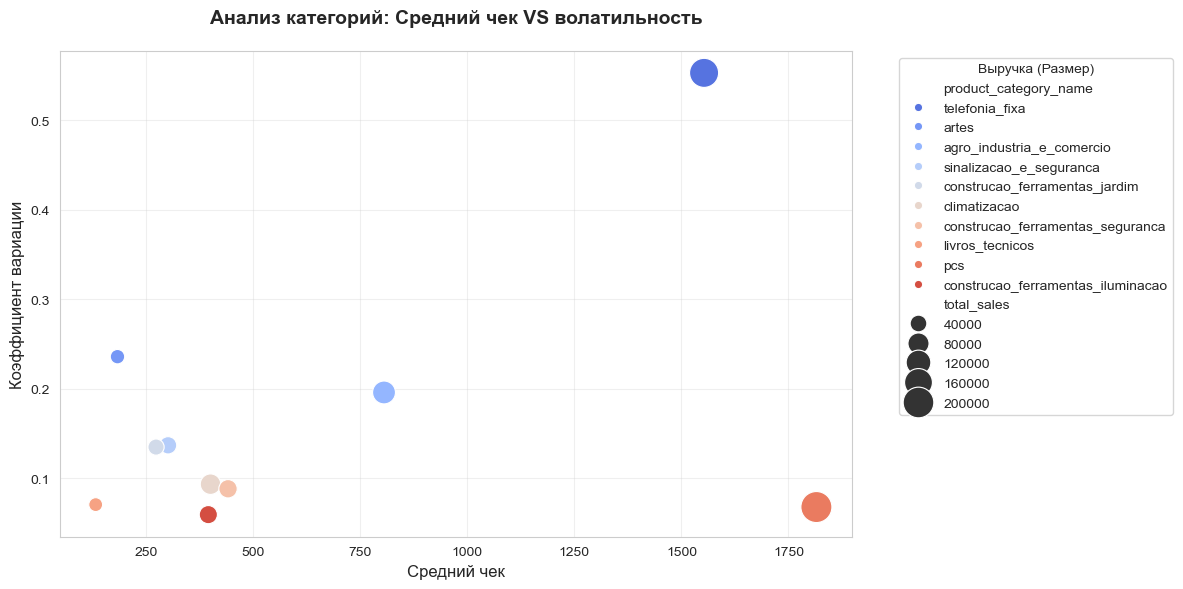

In [10]:
from style import setup_style, decorate
import matplotlib.pyplot as plt
import seaborn as sns

# Оставим только топ-10 самых нестабильных категорий
top10_cats = category_stats.sort_values(by = 'cv', ascending = False).head(10)
setup_style()
fig, ax = plt.subplots(figsize = (12, 6))
sns.scatterplot(data = top10_cats, x = 'total_aov', y = 'cv', marker = 'o', hue = 'product_category_name', size = 'total_sales', palette = 'coolwarm', sizes = (100, 500), ax = ax)
decorate(ax, 'Анализ категорий: Средний чек VS волатильность', 'Средний чек', 'Коэффициент вариации')
plt.legend(title = 'Выручка (Размер)', bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.tight_layout()


**Выводы по анализу категорий:** 
- Самая проблемная категория - "telefonia_fixa" - Стационарные телефоны. Данная категория демонстрирует малую общую выручку и очень высокую волатильность (0.55), что говорит о малых единичных заказах. От этого любое колебание спроса на эту категорию сильно влияет на её финансовые показатели. Также, затруднительно прогнозировать выручку по данной категории в дальнейшем
- Хедлайнер среди "нестабильных категорий" - pcs (ПК) данная категория демонстрирует большую, по сравнению с остальными, выручку и при этом низкую волатильность, что говорит о её стабильности и потенциале для дальнейшего развития. Данная категория обеспечивает весьма предсказуемый доход
- В остальном категории показывают стабильную, пусть и не всегда большую выручку, что говорит об их стабильности и возможности планировать их дальнейшие продажи 

**Перейдем к анализу логистических рисков по штатам**


In [17]:
# Сгруппируем данные по штатам и высчитаем от туда основные показатели
delivery_for_state = data.groupby('customer_state')['delivery_days'].agg(
    mean_delivery = 'mean',
    median_delivery = 'median',
    std_delivery = 'std',
    q90_delivery = lambda x: x.quantile(0.9)
    ).reset_index()

delivery_for_state.describe()

,mean_delivery,median_delivery,std_delivery,q90_delivery
count,27.000000,27.000000,27.000000,27.000000
mean,18.150263,15.925926,11.305322,29.192593
std,5.004029,4.706182,5.688843,6.757954
min,8.237097,7.000000,6.684102,15.000000
25%,14.831881,12.500000,7.873615,24.500000
50%,18.121212,16.000000,10.126685,29.400000
75%,20.721901,18.000000,11.714332,34.050000
max,28.862068,26.000000,30.909857,42.600000


**На основе полученного датафрейма создадим колонку, которая будет отражать риск по штату значениями от 1 до 3, где 1 - идеальный результат, 2 - зона риска, 3 - хаос. Ранжирование будет отталкиваться от средних значений по всем штатам**

In [27]:
# Создадим функцию, которая будет присваивать грейд штату в зависимость от выполнения условий
def get_score(row):
    if row['q90_delivery'] > 34 or row['std_delivery'] > 12:
        return '3'
    elif row['mean_delivery'] > 16 or row['std_delivery'] > 10:
        return '2'
    else:
        return '1'

# Создадим новую колонку в датафрейме и заполним её значениями, которые вернет функция в зависимости от выполнения условий
delivery_for_state['score'] = delivery_for_state.apply(get_score, axis=1)

delivery_for_state.head(10)

,customer_state,mean_delivery,median_delivery,std_delivery,q90_delivery,score
0,AC,19.094595,17.0,9.580472,29.4,2
1,AL,23.920000,21.0,12.031925,41.0,3
2,AM,25.592592,26.0,9.380272,37.6,3
3,AP,28.862068,24.0,30.909857,30.3,3
4,BA,18.634640,16.0,11.317509,31.0,2
5,CE,20.466843,18.0,13.086895,33.0,3
6,DF,12.390609,11.0,7.139849,21.0,1
7,ES,14.987946,13.0,9.244597,24.0,1
8,GO,15.066377,13.0,10.126685,24.0,2
9,MA,20.976959,19.0,11.187950,34.0,2


**Теперь, когда мы получили данные, отобразим логистические риски на карте Бразилии с помощью plotly и сторонней карты Бразилии (Её нет во встроенной библиотеке :< )**

In [13]:
import plotly.express as px
import requests

url = 

SyntaxError: invalid syntax (4067063598.py, line 4)

In [33]:
'''import geobr
import plotly.express as px

delivery_for_state['score_cat'] = delivery_for_state['score'].astype(str)

# 2. В самом графике меняем только одну строчку:
fig = px.choropleth(
    delivery_for_state,
    geojson=states_geo,
    locations='customer_state',
    featureidkey="properties.abbrev_state",
    color='score_cat',
    color_discrete_map={
        "1": "#2ca02c", 
        "2": "#ffcc00", 
        "3": "#d62728"  
    },
    category_orders={"score_cat": ["1", "2", "3"]}, 
    hover_data=['mean_delivery', 'std_delivery', 'q90_delivery'],
    title='Логистические риски Бразилии'
)
fig.update_geos(fitbounds="locations", visible=False)
fig.show()'''

'import geobr\nimport plotly.express as px\n\ndelivery_for_state[\'score_cat\'] = delivery_for_state[\'score\'].astype(str)\n\n# 2. В самом графике меняем только одну строчку:\nfig = px.choropleth(\n    delivery_for_state,\n    geojson=states_geo,\n    locations=\'customer_state\',\n    featureidkey="properties.abbrev_state",\n    color=\'score_cat\',\n    color_discrete_map={\n        "1": "#2ca02c", \n        "2": "#ffcc00", \n        "3": "#d62728"  \n    },\n    category_orders={"score_cat": ["1", "2", "3"]}, \n    hover_data=[\'mean_delivery\', \'std_delivery\', \'q90_delivery\'],\n    title=\'Логистические риски Бразилии\'\n)\nfig.update_geos(fitbounds="locations", visible=False)\nfig.show()'

Как видно из карты, самые проблемные штаты находятся на севере страны. Это объясняется тем, что север Бразилии представляет собой  джунгли, плохие дороги и ужасную логистику. Наоборот мы видим, что на юге страны, там, где распологаются самые богатые штаты и столица страны логистика работает исправно. В общем карта показывает, что чем дальше мы удаляемся от развитой части страны, тем ситуация с логистикой становится хуже. Это не проблема бизнеса как такового (Хотя желательно улучшать логистику во всех штатах и не допускать хаоса), это скорее особенности географии Бразилии